In [1]:
from sharadar.pipeline.engine import load_sharadar_bundle, symbol, symbols, make_pipeline_engine
bundle = load_sharadar_bundle()

[2025-08-02 21:42:17] INFO: A calendar with the name NYSEMKT is already registered.
[2025-08-02 21:42:17] INFO: Using bundle 'sharadar'.
[2025-08-02 21:42:17] INFO: Using bundle 'sharadar'.


[2025-08-02 21:42:17] INFO: Using trading calendar '2005-08-02 00:00:00'.
[2025-08-02 21:42:17] INFO: Backtest from 2000-06-30 to 2025-06-30.
[2025-08-02 21:42:17] INFO: Backtest from 2000-06-30 to 2025-06-30.


Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory


--- Generating Pyfolio Tear Sheet ---


Start date,2000-06-30
End date,2025-06-30
Total months,299
,Backtest
Annual return,6.534%
Cumulative returns,384.913%
Annual volatility,16.677%
Sharpe ratio,0.46
Calmar ratio,0.13
Stability,0.90
Max drawdown,-49.023%


...

/home/weekiang/sharadar_db_bundle/venv/lib/python3.8/site-packages/pyfolio/plotting.py:1373: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.boxplot(
/home/weekiang/sharadar_db_bundle/venv/lib/python3.8/site-packages/pyfolio/plotting.py:1401: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


Stress Events,mean,min,max
Dotcom,0.07%,-2.22%,1.58%
Lehman,-0.21%,-6.75%,3.52%
9/11,0.28%,-3.06%,3.74%
US downgrade/European Debt Crisis,-0.08%,-5.36%,3.78%
Fukushima,0.14%,-0.94%,1.66%
US Housing,-0.35%,-2.45%,1.80%
EZB IR Event,0.02%,-0.89%,1.27%
Aug07,0.08%,-2.68%,1.77%
Mar08,0.13%,-2.19%,3.66%
Sept08,-0.47%,-6.75%,3.52%


Top 10 long positions of all time,max
sid,
SPY,98.33%


Top 10 short positions of all time,max
sid,


Top 10 positions of all time,max
sid,
SPY,98.33%


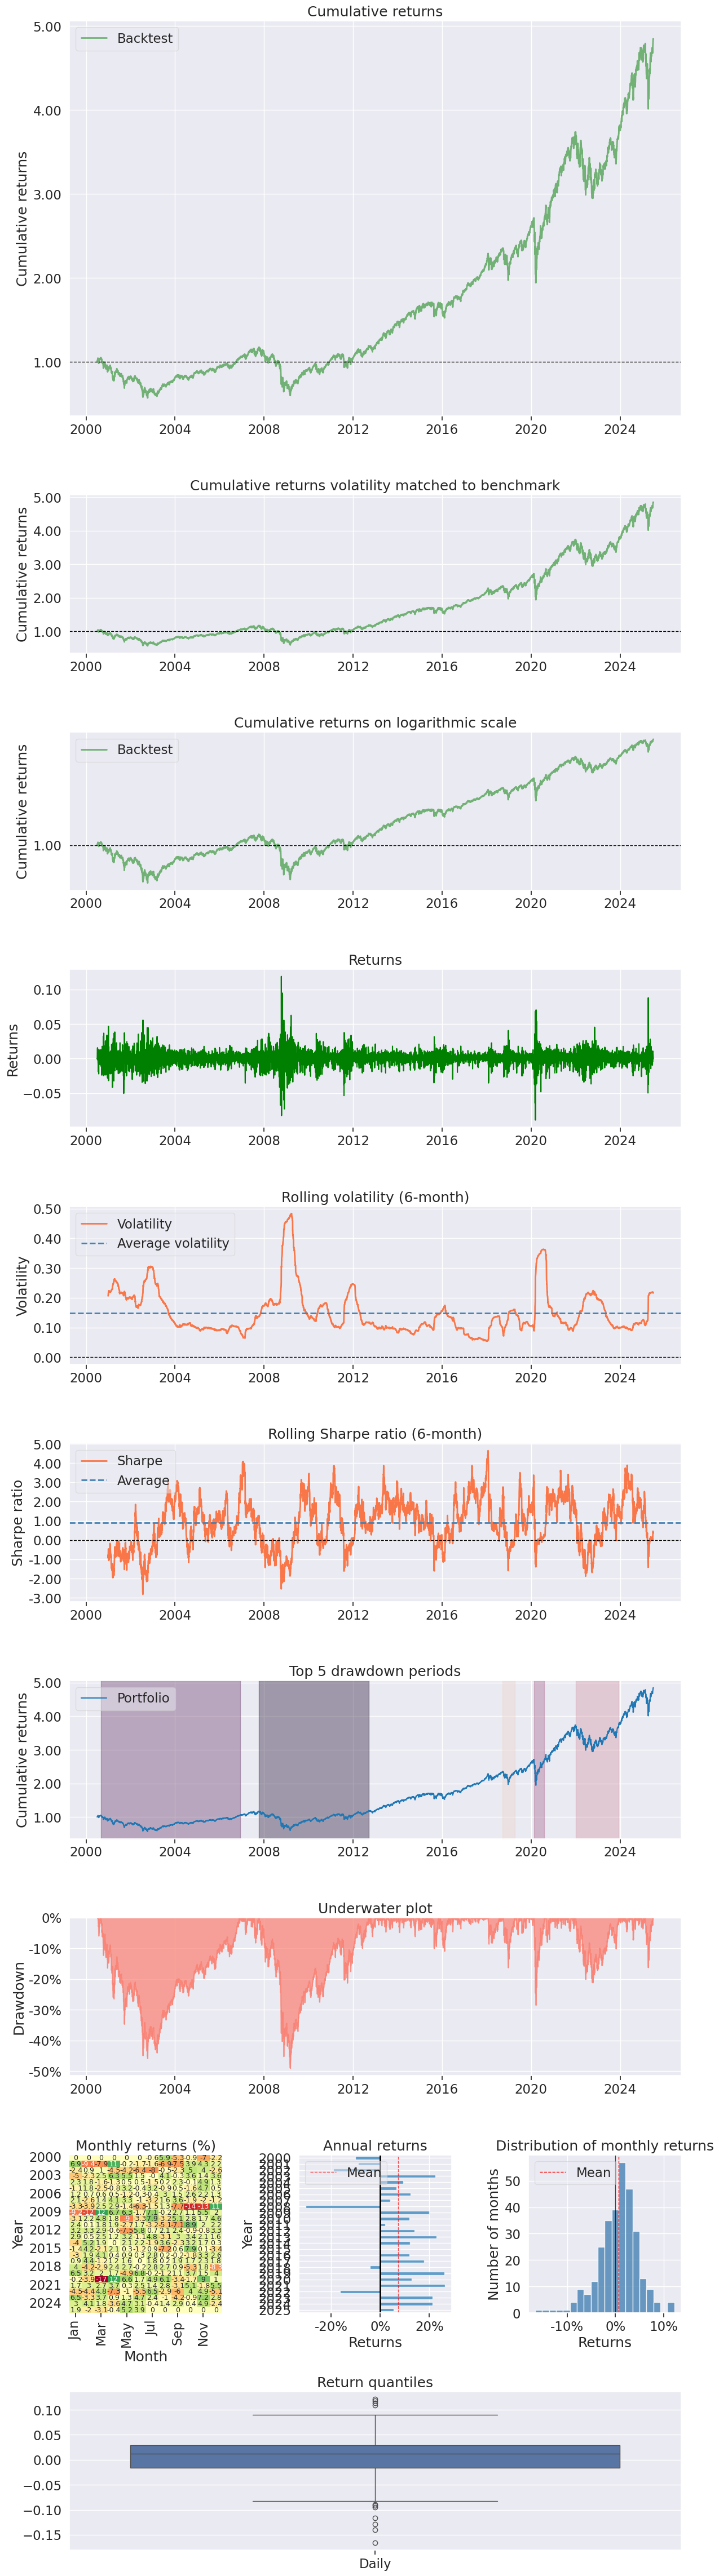

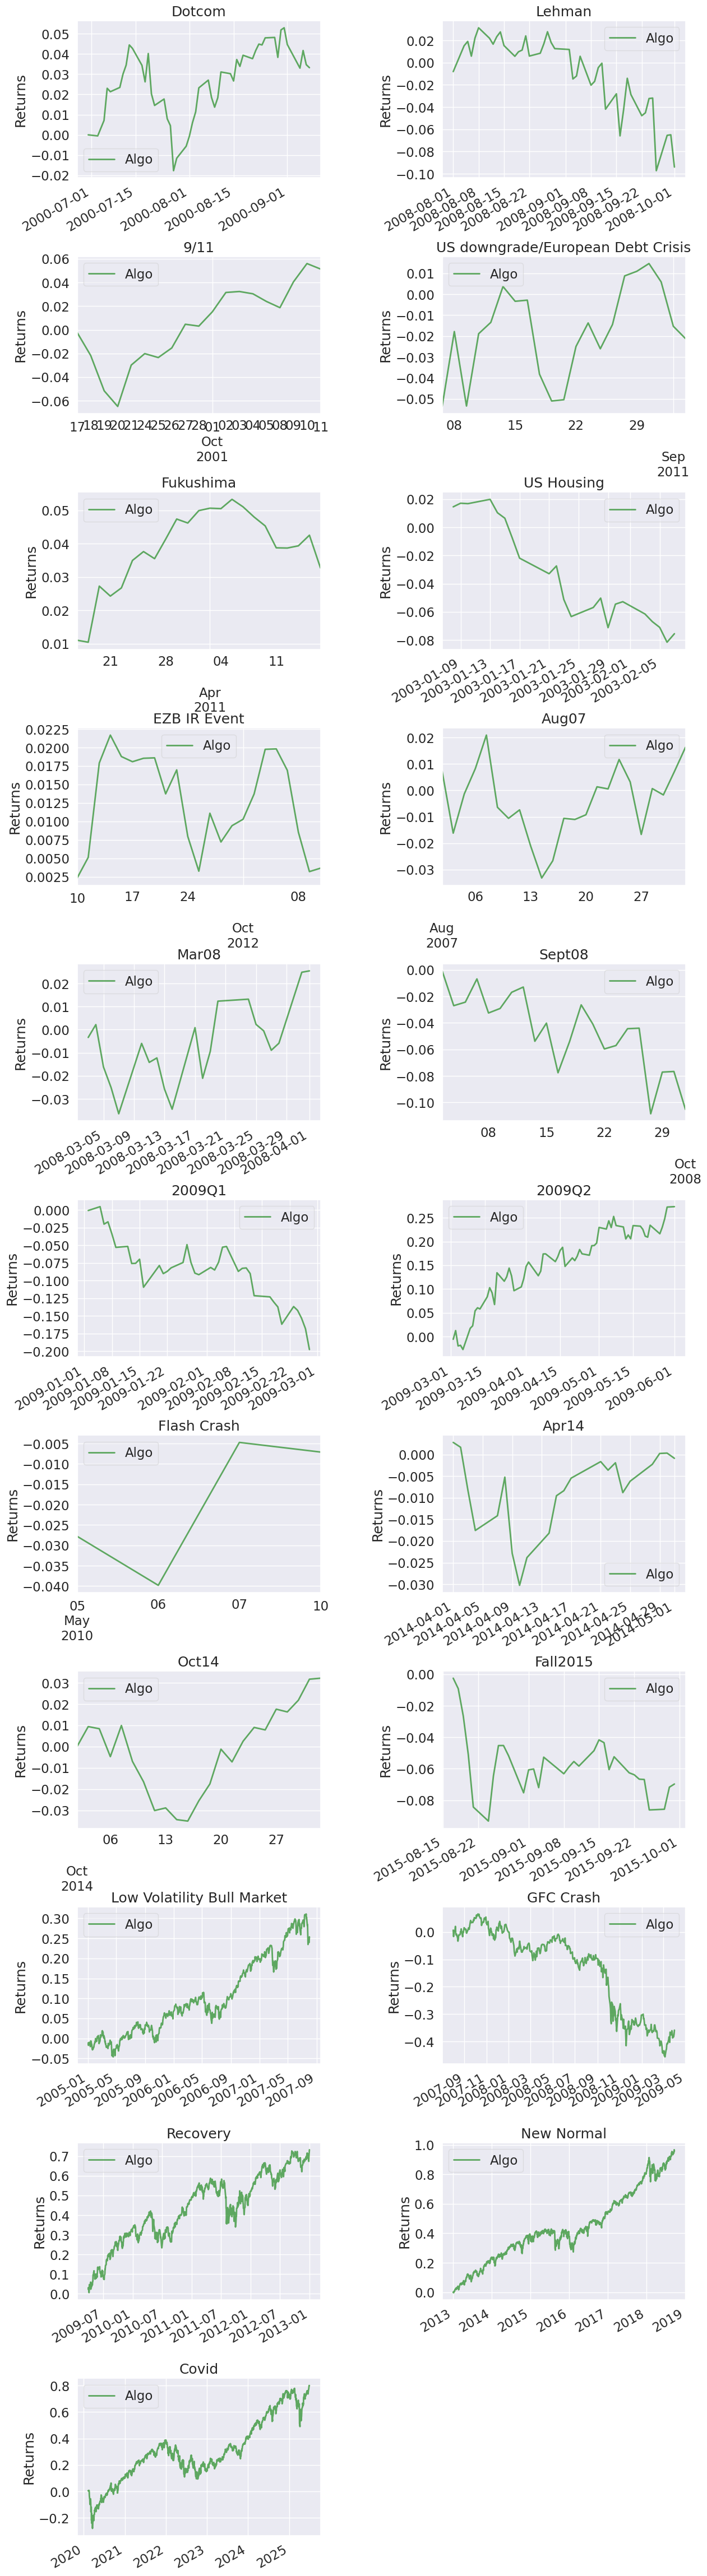

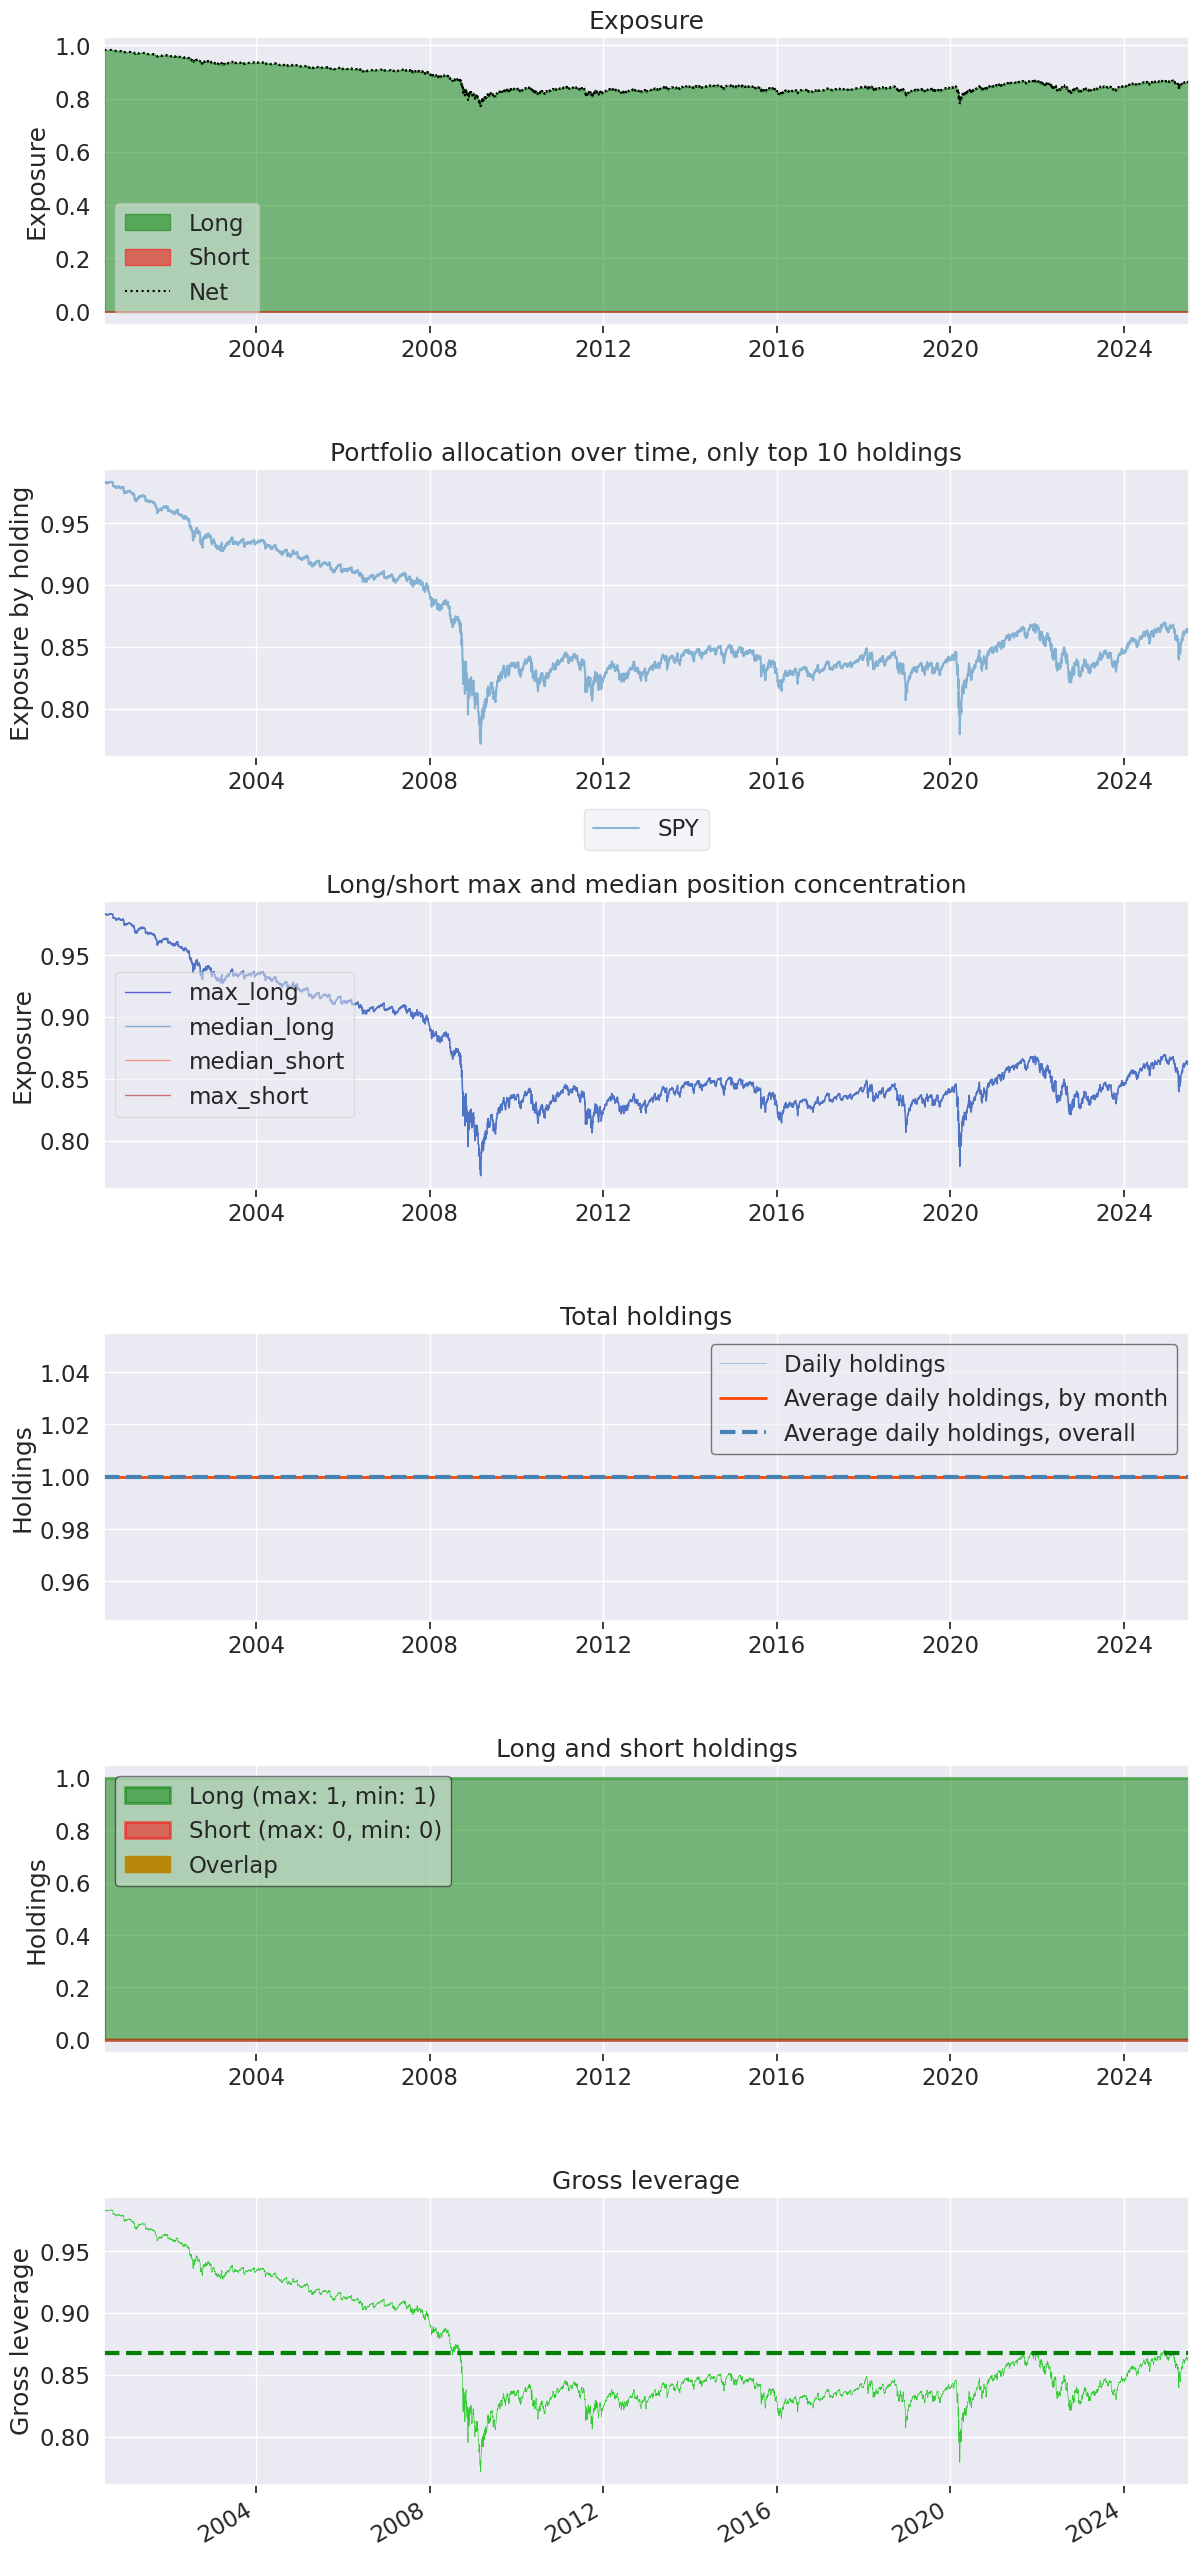

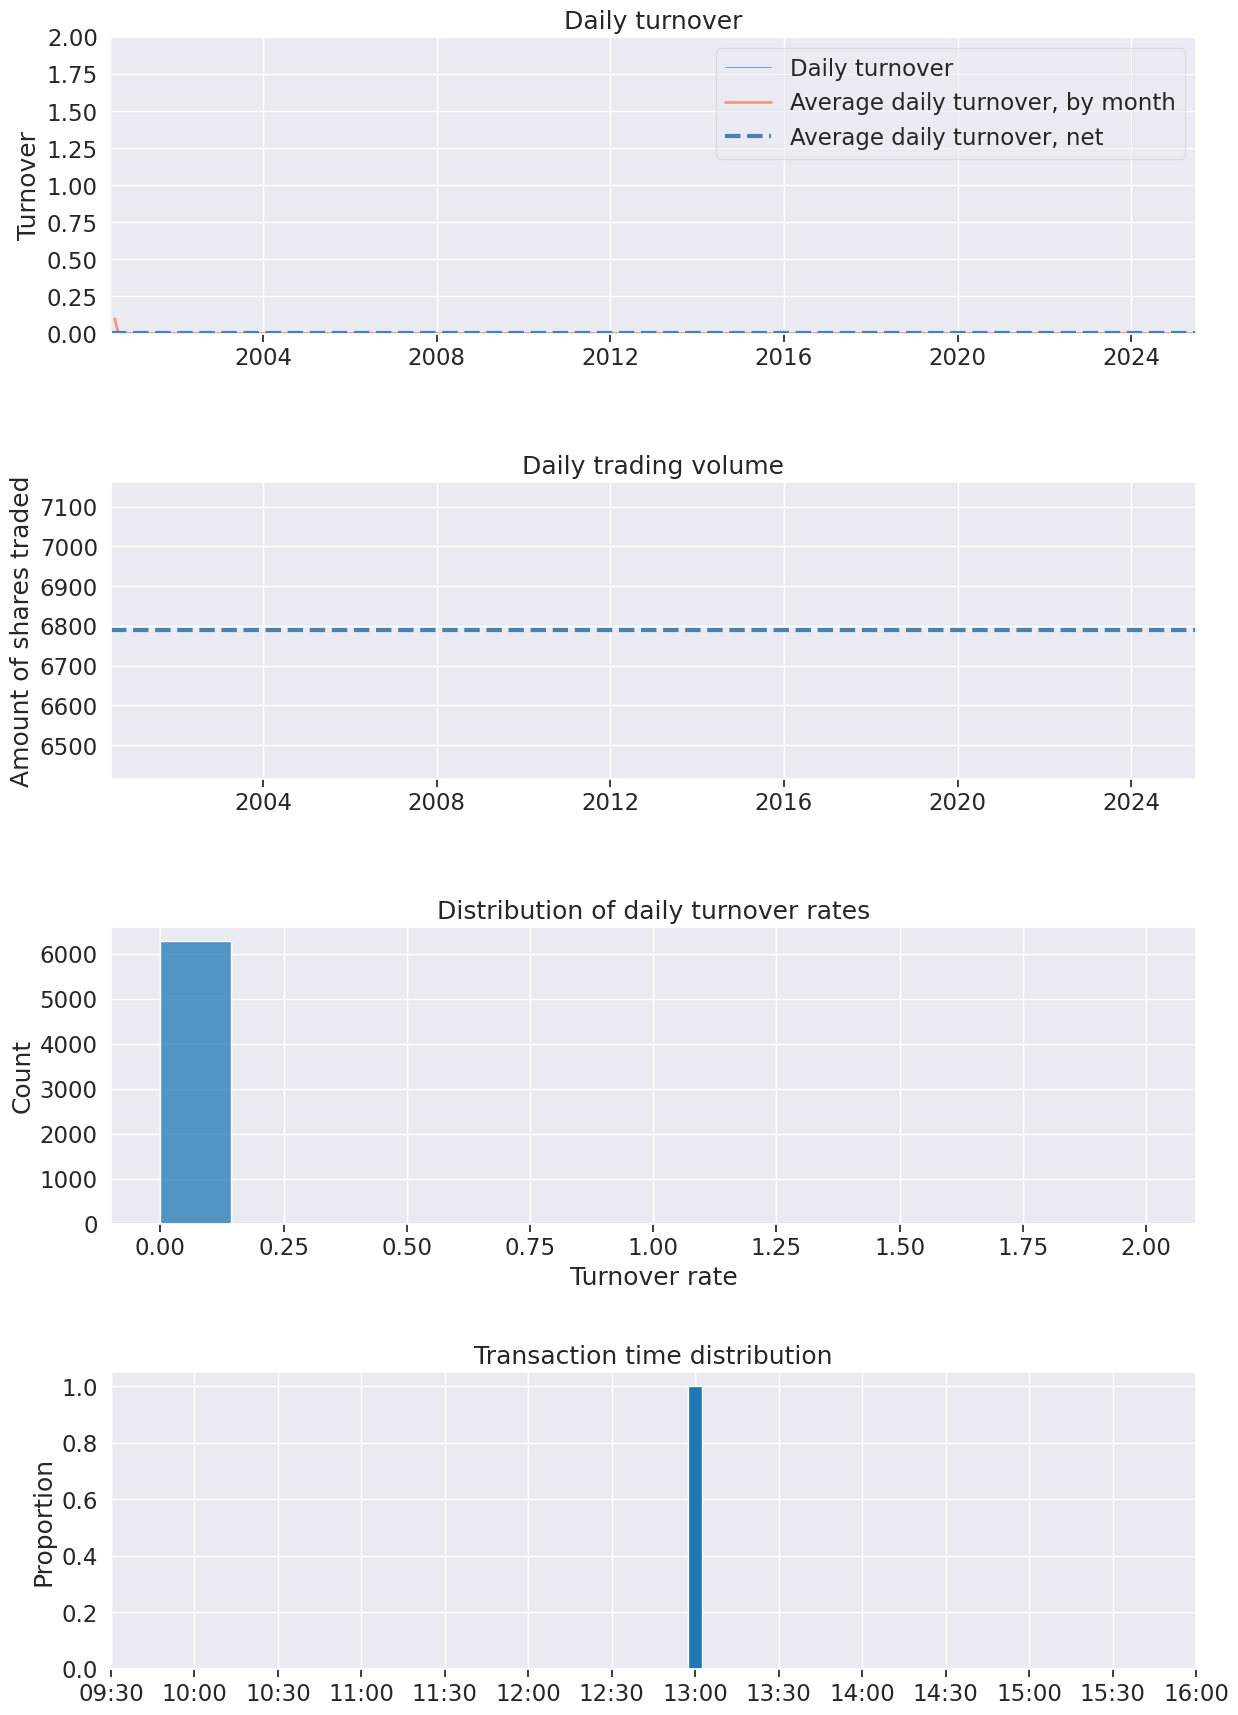

In [ ]:
%matplotlib inline

import pandas as pd
import pyfolio as pf
# Remove this import - it conflicts with sharadar's run_algorithm
# from zipline import run_algorithm
from sharadar.util.run_algo import run_algorithm  # Use this instead
from zipline.api import (
    order_target_percent,
    symbol,
    set_commission
)
#from zipline.utils.calendars import get_calendar
from zipline.finance.commission import PerShare
from zipline.utils.calendar_utils import get_calendar

# --- Initialization Function ---
def initialize(context):
    """
    Called once at the start of the algorithm.
    """
    # Define the stock to trade
    context.asset = symbol('SPY')
    
    # Use a flag to ensure we only trade once
    context.traded = False
    
    # Set a realistic commission model
    set_commission(PerShare(cost=0.005, min_trade_cost=1.0))

# --- Main Trading Logic ---
def handle_data(context, data):
    """
    Called on every trading event (daily or minute).
    """
    # We use the 'traded' flag to ensure the order is placed only once.
    if not context.traded:
        # Order 100% of our portfolio value in the specified asset.
        order_target_percent(context.asset, 1.0)
        # Set the flag to True so we don't trade again.
        context.traded = True

# --- Analysis Function ---
def analyze(context, perf):
    """
    Called once at the end of the algorithm.
    """
    print("--- Generating Pyfolio Tear Sheet ---")
    
    # Use Pyfolio to generate a standard performance report
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf)
    pf.create_full_tear_sheet(
        returns,
        positions=positions,
        transactions=transactions,
        round_trips=False  # Set to False because this is not a round-trip strategy
    )

# --- Backtest Execution ---
# Define the date range for the backtest
start_date = pd.to_datetime('2000-06-30')
end_date = pd.to_datetime('2025-06-30')

# Execute the algorithm using Sharadar's run_algorithm with error handling
try:
    results = run_algorithm(
        start=start_date,
        end=end_date,
        initialize=initialize,
        handle_data=handle_data,
        analyze=analyze,
        capital_base=1000000,
        data_frequency='daily',
        bundle='sharadar'  # Use bundle name string instead of bundle object
    )
except ValueError as e:
    if "metrics set" in str(e) and "already registered" in str(e):
        print("Metrics already registered. Please restart the kernel and run cells in order.")
        print("Or try running without the analyze function first.")
    else:
        raise e